# Imputation Techniques

In [1]:
import seaborn as sns
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## List-wise Deletion (CCA)

In [2]:
import numpy as np

data = np.array([
    [1, 2, 3],
    [4, np.nan, 6],
    [7, 8, 9]
])

def CCA(np_arr):
    complete_rows_mask = ~np.isnan(np_arr).any(axis = 1)
    return np_arr[complete_rows_mask]
def CCA(df):
    return df.dropna()
CCA(df)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False
872,0,1,male,33.0,0,0,5.0000,S,First,man,True,B,Southampton,no,True
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True


## Mean, Meadian, Mode Imputation

In [3]:
import pandas as pd
from statistics import mode

data = {
    "Age": [25, 30, 28, None, 32, 40, None, 29],
    "Color": ["Red", "Blue", None, "Blue", "Green", None, "Blue", None]
}

df = pd.DataFrame(data)
print("Original data")
print(df)

# Mean Imputation
mean_age = df["Age"].mean()
df["Age_mean_imputed"] = df["Age"].fillna(mean_age)

# Median Imputation
med_age = df["Age"].median()
df["Age_median_imputed"] = df["Age"].fillna(med_age)

# Mode Imputation
mode = df["Color"].mode()
df["Color_mode_imputed"] = df["Color"].fillna(mode[0])

df

Original data
    Age  Color
0  25.0    Red
1  30.0   Blue
2  28.0   None
3   NaN   Blue
4  32.0  Green
5  40.0   None
6   NaN   Blue
7  29.0   None


,Age,Color,Age_mean_imputed,Age_median_imputed,Color_mode_imputed
0,25.0,Red,25.000000,25.0,Red
1,30.0,Blue,30.000000,30.0,Blue
2,28.0,None,28.000000,28.0,Blue
3,NaN,Blue,30.666667,29.5,Blue
4,32.0,Green,32.000000,32.0,Green
5,40.0,None,40.000000,40.0,Blue
6,NaN,Blue,30.666667,29.5,Blue
7,29.0,None,29.000000,29.0,Blue


In [4]:
import pandas as pd
from sklearn.impute import SimpleImputer

data = {
    "Age": [25, 30, 28, None, 32, 40, None, 29],
    "Color": ["Red", "Blue", None, "Blue", "Green", None, "Blue", None]
}

df = pd.DataFrame(data)
print("Original data")
print(df)


mean_imputer = SimpleImputer(strategy = "mean").fit(df[["Age"]])
median_imputer = SimpleImputer(strategy = "median").fit(df[["Age"]])
mode_imputer = SimpleImputer(strategy = "most_frequent", missing_values = None).fit(df[["Color"]])
df["Age_mean_imputed"] = mean_imputer.transform(df[["Age"]])
df["Age_median_imputed"] = median_imputer.transform(df[["Age"]])
df["Color_mode_imputed"] = mode_imputer.transform(df[["Color"]]).ravel()

df

Original data
    Age  Color
0  25.0    Red
1  30.0   Blue
2  28.0   None
3   NaN   Blue
4  32.0  Green
5  40.0   None
6   NaN   Blue
7  29.0   None


,Age,Color,Age_mean_imputed,Age_median_imputed,Color_mode_imputed
0,25.0,Red,25.000000,25.0,Red
1,30.0,Blue,30.000000,30.0,Blue
2,28.0,None,28.000000,28.0,Blue
3,NaN,Blue,30.666667,29.5,Blue
4,32.0,Green,32.000000,32.0,Green
5,40.0,None,40.000000,40.0,Blue
6,NaN,Blue,30.666667,29.5,Blue
7,29.0,None,29.000000,29.0,Blue


## K-NN Imputation 

In [65]:
from sklearn.impute import KNNImputer
import pandas as pd

data = {
    'Feature1': [1.0, 2.0, np.nan, 4.0],
    'Feature2': [np.nan, 2.0, 3.0, 4.0],
    'Feature3': [1.0, 2.0, 3.0, np.nan]
}
df = pd.DataFrame(data)

imputer = KNNImputer(n_neighbors=2)
imputed_df = imputer.fit_transform(df)
imputed_df

array([[1. , 2.5, 1. ],
       [2. , 2. , 2. ],
       [3. , 3. , 3. ],
       [4. , 4. , 2.5]])

## MICE Imputation

In [74]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

data = {
    'Feature1': [1.0, 2.0, np.nan, 4.0],
    'Feature2': [np.nan, 2.0, 3.0, 4.0],
    'Feature3': [1.0, 2.0, 3.0, np.nan]
}
df = pd.DataFrame(data)

imputer = IterativeImputer(random_state=100,)
imputed_df = imputer.fit_transform(df)
imputed_df

array([[1.        , 2.7620889 , 1.        ],
       [2.        , 2.        , 2.        ],
       [4.99997249, 3.        , 3.        ],
       [4.        , 4.        , 1.85523654]])

# Outlier Detection

Original
   value  score
0     10     50
1     12     52
2     11     49
3     13     51
4     12    800
5    500     48
6      9     47
7      8    900
8     11     50
9    600     49


 Outlier IQR
Removal
   value  score
0     10     50
1     12     52
2     11     49
3     13     51
4     12    800
6      9     47
7      8    900
8     11     50


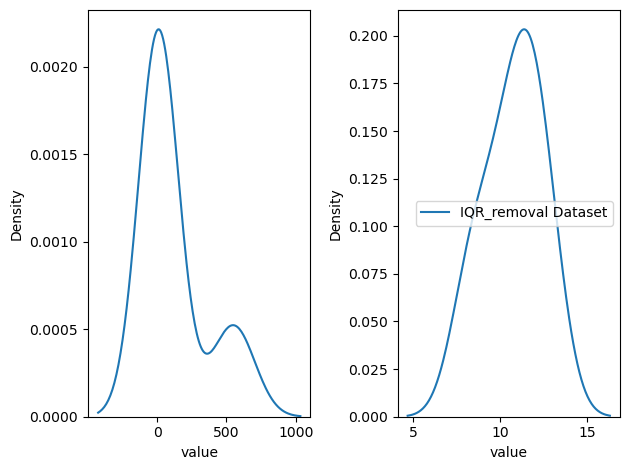


Capping
   value  score
0   10.0     50
1   12.0     52
2   11.0     49
3   13.0     51
4   12.0    800
5   16.5     48
6    9.0     47
7    8.0    900
8   11.0     50
9   16.5     49


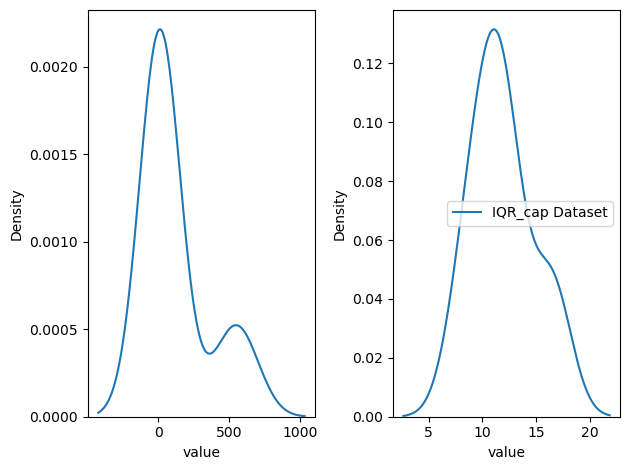



 Outlier Z_Score
Removal
   value  score
0     10     50
1     12     52
2     11     49
3     13     51
4     12    800
5    500     48
6      9     47
7      8    900
8     11     50
9    600     49


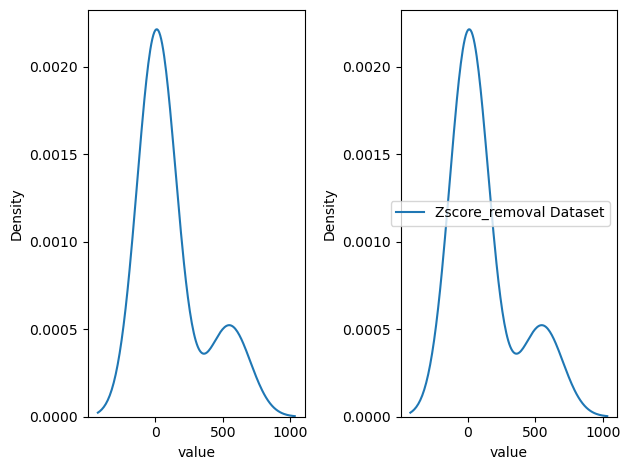


Capping
upper cap: 575.7818991264734
lower cap: -338.58189912647333
        value  score
0   10.000000     50
1   12.000000     52
2   11.000000     49
3   13.000000     51
4   12.000000    800
5  500.000000     48
6    9.000000     47
7    8.000000    900
8   11.000000     50
9  575.781899     49


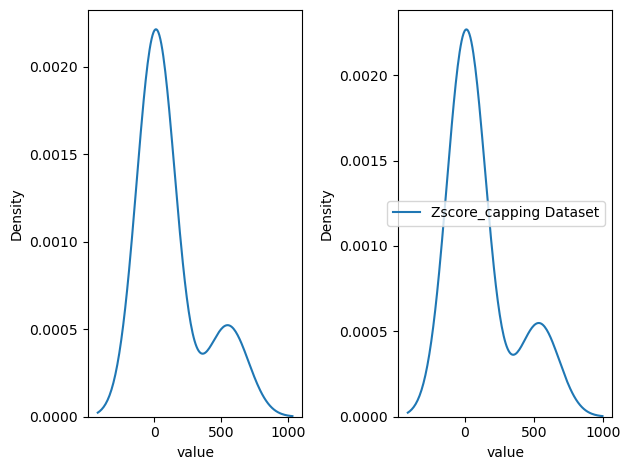

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def remove_outliers_IQR(df, feature, delta = 1.5):
    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)
    iqr = q3 - q1

    filter_value = (df[feature] >= q1 - (delta * iqr)) & (df[feature] <= q3 + (delta * iqr))
    df = df.loc[filter_value]
    return df

def remove_outliers_ZScore(df, feature, threshold = 3):
    z_score = (df[feature] - df[feature].mean()) / df[feature].std()
    df = df[z_score.abs() <= threshold]
    return df

def cap_outliers_IQR(df, feature, delta = 1.5):
    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)
    iqr = q3 - q1
    df[feature] = np.where(df[feature] < q1 - (delta * iqr), q1 - (delta * iqr), df[feature])
    df[feature] = np.where(df[feature] > q3 + (delta * iqr), q3 + (delta * iqr), df[feature])

    return df



def cap_outliers_ZScore(df, feature, threshold=2):
    data = df.copy()
    
    mean = data[feature].mean()
    std = data[feature].std()

    if std == 0:
        print(f"No variation in {feature}, skipping capping.")
        return data

    upper_cap = mean + threshold * std
    lower_cap = mean - threshold * std

    print("upper cap:", upper_cap)
    print("lower cap:", lower_cap)

    data[feature] = np.clip(data[feature], lower_cap, upper_cap)

    return data



# df = pd.read_csv("C:/Users/USER/Downloads/data_demo.csv")
# print(df)
# remove_outliers_IQR(df, "value")
# cap_outliers_IQR(df, "value")


df = pd.DataFrame({
    "value": [10, 12, 11, 13, 12, 500, 9, 8, 11, 600],
    "score": [50, 52, 49, 51, 800, 48, 47, 900, 50, 49]
})
print("Original")
print(df)

print("\n\n Outlier IQR")
print("Removal")
IQR_removal = remove_outliers_IQR(df.copy(), "value")
print(IQR_removal)
plt.subplot(1, 2, 1)
sns.kdeplot(df["value"], label = "Original Dataset")
plt.subplot(1, 2, 2)
sns.kdeplot(IQR_removal["value"], label = "IQR_removal Dataset")
plt.tight_layout()
plt.legend()
plt.show()

print("\nCapping")
IQR_cap = cap_outliers_IQR(df.copy(), "value")
print(IQR_cap)
plt.subplot(1, 2, 1)
sns.kdeplot(df["value"], label = "Original Dataset")
plt.subplot(1, 2, 2)
sns.kdeplot(IQR_cap["value"], label = "IQR_cap Dataset")
plt.tight_layout()
plt.legend()
plt.show()



print("\n\n Outlier Z_Score")
print("Removal")
Zscore_removal = remove_outliers_ZScore(df.copy(), "value")
print(Zscore_removal)
plt.subplot(1, 2, 1)
sns.kdeplot(df["value"], label = "Original Dataset")
plt.subplot(1, 2, 2)
sns.kdeplot(Zscore_removal["value"], label = "Zscore_removal Dataset")
plt.tight_layout()
plt.legend()
plt.show()

print("\nCapping")
Zscore_capping = cap_outliers_ZScore(df.copy(), "value")
print(Zscore_capping)
plt.subplot(1, 2, 1)
sns.kdeplot(df["value"], label = "Original Dataset")
plt.subplot(1, 2, 2)
sns.kdeplot(Zscore_capping["value"], label = "Zscore_capping Dataset")
plt.tight_layout()
plt.legend()
plt.show()

# Standardization
#### (Z-Score scaling)
___
- Standardization is the process of centering the variable at 
zero and standardizing the data variance to 1. 
- It is done using z-score

$$
z = \frac{x - \mu}{\sigma}
$$

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler

plt.rcParams["figure.figsize"] = [8,6]
sns.set_style("darkgrid")

titanic_data = sns.load_dataset("titanic")

titanic_data = titanic_data[["age", "fare", "pclass"]]
titanic_data.describe()

,age,fare,pclass
count,714.000000,891.000000,891.000000
mean,29.699118,32.204208,2.308642
std,14.526497,49.693429,0.836071
min,0.420000,0.000000,1.000000
25%,20.125000,7.910400,2.000000
50%,28.000000,14.454200,3.000000
75%,38.000000,31.000000,3.000000
max,80.000000,512.329200,3.000000


In [7]:
scaler = StandardScaler()
scaler.fit(titanic_data)
titanic_data_scaled = scaler.transform(titanic_data)
titanic_data_scaled = pd.DataFrame(titanic_data_scaled, columns=titanic_data.columns)
titanic_data_scaled.head()

,age,fare,pclass
0,-0.530377,-0.502445,0.827377
1,0.571831,0.786845,-1.566107
2,-0.254825,-0.488854,0.827377
3,0.365167,0.420730,-1.566107
4,0.365167,-0.486337,0.827377


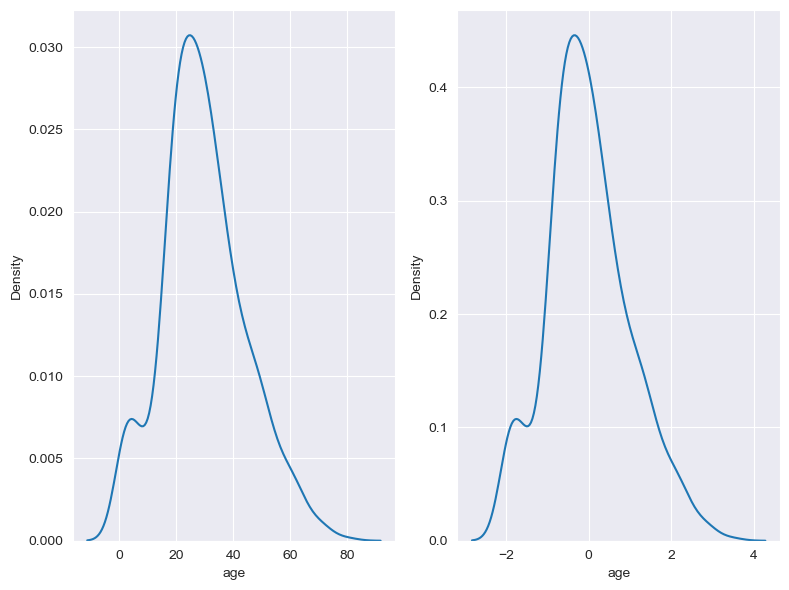

In [8]:
plt.subplot(1,2,1)
sns.kdeplot(titanic_data["age"], label = "Original")
plt.subplot(1,2,2)
sns.kdeplot(titanic_data_scaled["age"], label = "Scaled")
plt.tight_layout()

# Normalization
#### (Min/Max Scaling)

___

- Normalization is the process of rescaling the numerical data so that it fit within a smaller range, usually 0 - 1
- The formula is
$$
x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}
$$

In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(titanic_data)
titanic_data_norm = scaler.transform(titanic_data)
titanic_data_norm = pd.DataFrame(titanic_data_norm, columns=titanic_data.columns)
titanic_data_norm.head()

,age,fare,pclass
0,0.271174,0.014151,1.0
1,0.472229,0.139136,0.0
2,0.321438,0.015469,1.0
3,0.434531,0.103644,0.0
4,0.434531,0.015713,1.0


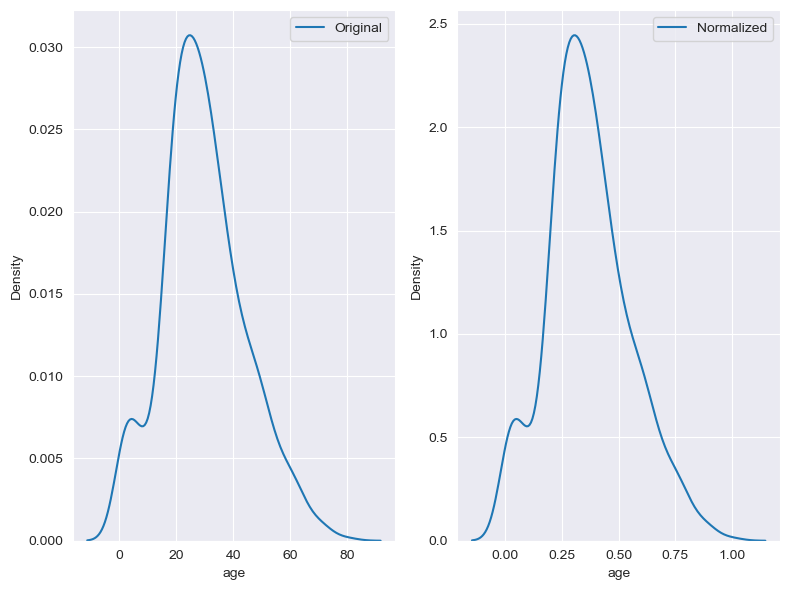

In [10]:
plt.subplot(1,2,1)
sns.kdeplot(titanic_data["age"], label = "Original")
plt.legend()
plt.subplot(1, 2, 2)
sns.kdeplot(titanic_data_norm["age"], label = "Normalized")
plt.legend()
plt.tight_layout()
plt.show()

# Robust Scaling

- It is a data preprocessing technique that scales the features using the median and the IQR instead of mean and standard deviation
- The formula is
$$
x' = \frac{x - meadian}{IQR}
$$

        age      fare  pclass
0 -0.335664 -0.312011     0.0
1  0.559441  2.461242    -2.0
2 -0.111888 -0.282777     0.0
3  0.391608  1.673732    -2.0
4  0.391608 -0.277363     0.0
5       NaN -0.259680     0.0
6  1.454545  1.620136    -2.0
7 -1.454545  0.286744     0.0
8 -0.055944 -0.143827     0.0
9 -0.783217  0.676348    -1.0


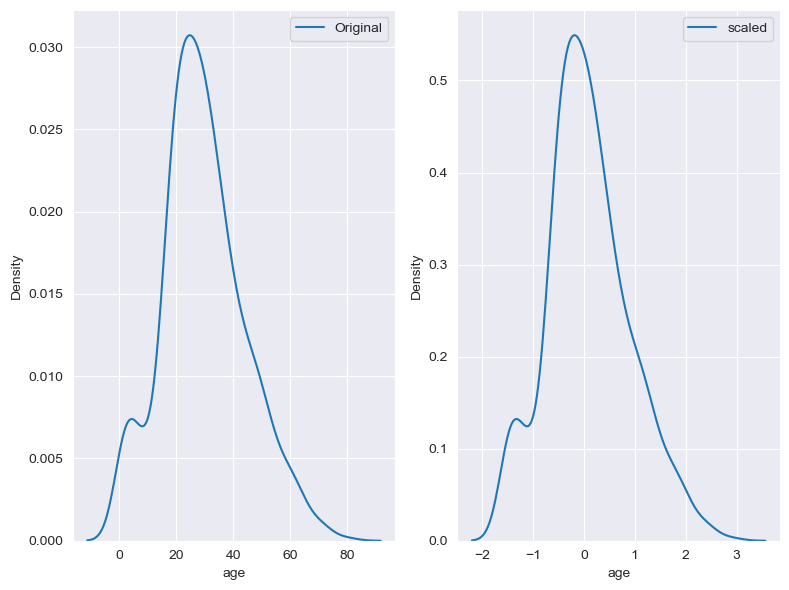

In [11]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
scaler.fit(titanic_data)
titanic_data_scaled = scaler.transform(titanic_data)
titanic_data_scaled = pd.DataFrame(titanic_data_scaled, columns=titanic_data.columns)
print(titanic_data_scaled.head(10))

plt.subplot(1, 2, 1)
sns.kdeplot(titanic_data["age"], label = "Original")
plt.legend()

plt.subplot(1, 2, 2)
sns.kdeplot(titanic_data_scaled["age"], label = "scaled")
plt.legend()

plt.tight_layout()
plt.show()

# Log and Square root Transformation

    views
0     200
1     250
2     300
3     400
4     500
5   20000
6   50000
7  120000


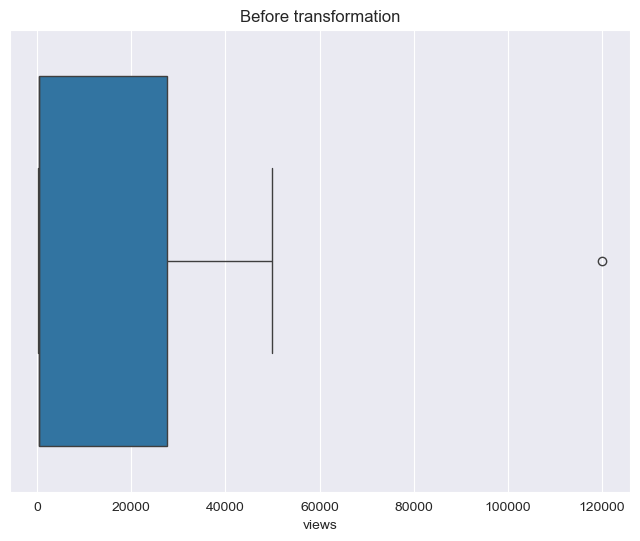

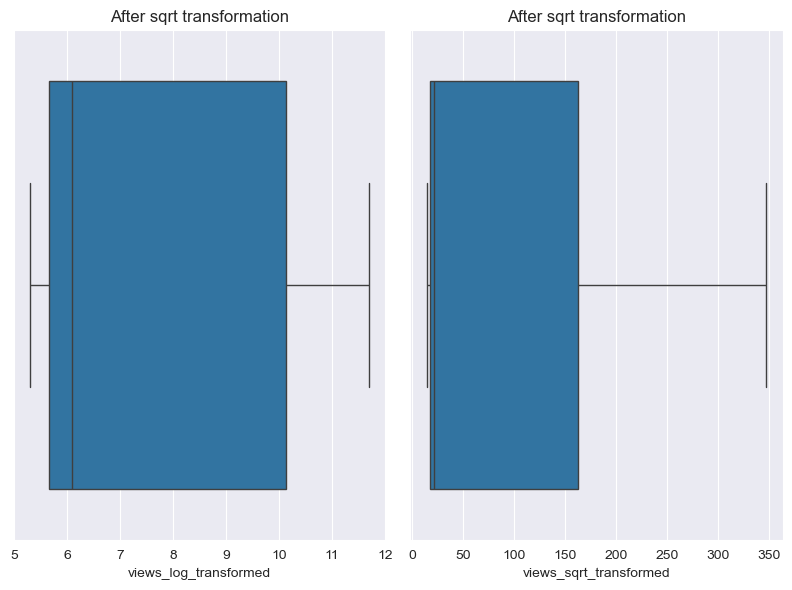

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.DataFrame({
    "views": [200, 250, 300, 400, 500, 20000, 50000, 120000]
})
print(df)
plt.figure(figsize=(8,6))
sns.boxplot(x=df["views"])
plt.title("Before transformation")
plt.show()

df["views_log_transformed"] = df["views"].apply(lambda x : np.log(x))
df["views_sqrt_transformed"] = df["views"].apply(lambda x : np.sqrt(x))

plt.figure(figsize=(8,6))
plt.subplot(1,2,1)
sns.boxplot(x=df["views_log_transformed"])
plt.title("After sqrt transformation")

plt.subplot(1,2,2)
sns.boxplot(x=df["views_sqrt_transformed"])
plt.title("After sqrt transformation")
plt.tight_layout()
plt.show()


# Feature Engineering

## Transformation (Polynomial feature)

In [13]:
from sklearn.preprocessing import PolynomialFeatures 

# Handle NaN
for i in titanic_data_scaled:
    mean = titanic_data_scaled[i].mean()
    titanic_data_scaled[i] = titanic_data_scaled[i].fillna(mean)

trans = PolynomialFeatures(degree=2)
trans.fit(titanic_data_scaled)

titanic_data_trans = trans.transform(titanic_data_scaled)
titanic_data_trans = pd.DataFrame(titanic_data_trans, columns=trans.get_feature_names_out(titanic_data_scaled.columns))
titanic_data_trans

,1,age,fare,pclass,age^2,age fare,age pclass,fare^2,fare pclass,pclass^2
0,1.0,-0.335664,-0.312011,0.0,0.112671,0.104731,-0.000000,0.097351,-0.000000,0.0
1,1.0,0.559441,2.461242,-2.0,0.312974,1.376919,-1.118881,6.057714,-4.922485,4.0
2,1.0,-0.111888,-0.282777,0.0,0.012519,0.031639,-0.000000,0.079963,-0.000000,0.0
3,1.0,0.391608,1.673732,-2.0,0.153357,0.655447,-0.783217,2.801378,-3.347464,4.0
4,1.0,0.391608,-0.277363,0.0,0.153357,-0.108618,0.000000,0.076930,-0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...
886,1.0,-0.055944,-0.062981,-1.0,0.003130,0.003523,0.055944,0.003967,0.062981,1.0
887,1.0,-0.503497,0.673281,-2.0,0.253509,-0.338995,1.006993,0.453308,-1.346563,4.0
888,1.0,0.095056,0.389604,0.0,0.009036,0.037034,0.000000,0.151791,0.000000,0.0
889,1.0,-0.111888,0.673281,-2.0,0.012519,-0.075332,0.223776,0.453308,-1.346563,4.0


# One hot encoding 

In [14]:
titanic_data_categorical =sns.load_dataset("titanic")[["sex", "class", "embark_town"]]
print(titanic_data_categorical)
for col in titanic_data_categorical.columns:
    print(titanic_data_categorical[col].unique())


temp = pd.get_dummies(titanic_data_categorical).astype(int)
temp.head()

        sex   class  embark_town
0      male   Third  Southampton
1    female   First    Cherbourg
2    female   Third  Southampton
3    female   First  Southampton
4      male   Third  Southampton
..      ...     ...          ...
886    male  Second  Southampton
887  female   First  Southampton
888  female   Third  Southampton
889    male   First    Cherbourg
890    male   Third   Queenstown

[891 rows x 3 columns]
['male' 'female']
['Third', 'First', 'Second']
Categories (3, object): ['First', 'Second', 'Third']
['Southampton' 'Cherbourg' 'Queenstown' nan]


,sex_female,sex_male,class_First,class_Second,class_Third,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton
0,0,1,0,0,1,0,0,1
1,1,0,1,0,0,1,0,0
2,1,0,0,0,1,0,0,1
3,1,0,1,0,0,0,0,1
4,0,1,0,0,1,0,0,1


# Label Encoding

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le_titanic_data = pd.DataFrame()
for col in titanic_data_categorical:   
    le.fit(titanic_data_categorical[col])
    le_titanic_data[col] = le.transform(titanic_data_categorical[col])


le_titanic_data.head(10)

,sex,class,embark_town
0,1,2,2
1,0,0,0
2,0,2,2
3,0,0,2
4,1,2,2
5,1,2,1
6,1,0,2
7,1,2,2
8,0,2,2
9,0,1,0


# Feture Selection Methods
___
## 1. Filter Methods
### Correlation Filter

In [16]:
import pandas as pd 
import numpy as np
import seaborn as sns

penguins_df = sns.load_dataset("penguins")
numeric_df = penguins_df.select_dtypes(include = ['float64', 'int64'])
corr_mat = numeric_df.corr().abs()
upper = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))

threshold = 0.8
to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
df_corr_filter = penguins_df.drop(columns=to_drop)
print("Shape of oiginal df : ", penguins_df.shape)
print("Shape of filtered df : ", df_corr_filter.shape)
corr_mat

Shape of oiginal df :  (344, 7)
Shape of filtered df :  (344, 6)


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,0.235053,0.656181,0.595110
bill_depth_mm,0.235053,1.000000,0.583851,0.471916
flipper_length_mm,0.656181,0.583851,1.000000,0.871202
body_mass_g,0.595110,0.471916,0.871202,1.000000


### Variance Threshold

In [33]:
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns

df = sns.load_dataset("penguins")
numeric_df = df.select_dtypes(["float64", "int64"])

# scaler = MinMaxScaler()
# scaler.fit(numeric_df)
# scaled_df = scaler.transform(numeric_df)
# scaled_df = pd.DataFrame(scaled_df, columns=numeric_df.columns)


sel = VarianceThreshold(threshold=0.05)
sel.fit(scaled_df)
df_variance_thresh = sel.transform(scaled_df)

df_variance_thresh = pd.DataFrame(
    df_variance_thresh,
    columns=scaled_df.columns[sel.get_support()]
)

df_variance_thresh

,bill_depth_mm,flipper_length_mm
0,0.666667,0.152542
1,0.511905,0.237288
2,0.583333,0.389831
3,NaN,NaN
4,0.738095,0.355932
...,...,...
339,NaN,NaN
340,0.142857,0.728814
341,0.309524,0.847458
342,0.202381,0.677966


## 2. Wrapper methods 
### RFE - Recursive Feature Elimination

In [54]:
from sklearn.feature_selection import RFE, SequentialFeatureSelector
import seaborn as sns
from sklearn.linear_model import LogisticRegression
import pandas as pd
from sklearn.preprocessing import LabelEncoder

titanic = sns.load_dataset("titanic")
df = titanic[["survived", "sex", "age", "fare", "class", "alone"]]
df = df.dropna()

le = LabelEncoder()
for col in df.select_dtypes(exclude = ["float64", "int64"]).columns:
    df[col] = le.fit_transform(df[col])

X = df.drop("survived", axis = 1)
target = df["survived"]

model = LogisticRegression(max_iter=2000)
rfe = RFE(model, n_features_to_select=3)
rfe.fit(X, target)

print("Selected Columns are : ", X.columns[rfe.support_])
print("Ranking")
for col, rank in zip(X.columns, rfe.ranking_):
    print(f"{col} : {rank}")


Selected Columns are :  Index(['sex', 'class', 'alone'], dtype='object')
Ranking
sex : 1
age : 2
fare : 3
class : 1
alone : 1


## Forward Feature Slection

In [63]:
from sklearn.feature_selection import SequentialFeatureSelector as SFS
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
import seaborn as sns

titanic = sns.load_dataset("titanic")
df =  titanic[["survived", "sex", "age", "fare", "class", "alone"]]
df = df.dropna()

le = LabelEncoder()
for col in df.select_dtypes(exclude=["int64", "float64"]).columns:
    df[col] = le.fit_transform(df[col])

X = df.drop("survived", axis = 1)
target = df["survived"]

model = LogisticRegression(max_iter=1000)
sfs = SFS(model, n_features_to_select=3, direction="forward")
sfs.fit(X, target)

print("Selected Columns are : ", X.columns[sfs.support_])


Selected Columns are :  Index(['sex', 'age', 'class'], dtype='object')
